In [1]:
# [CELL 1] CÀI ĐẶT THƯ VIỆN VÀ KIỂM TRA GPU
import sys
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
# Cài đặt thư viện vẽ thanh tiến trình (nếu Colab chưa có bản mới nhất)
!pip install -q tqdm
from tqdm.notebook import tqdm

# Kiểm tra sức mạnh vũ khí
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("==================================================")
if device.type == 'cuda':
    print(f"🔥 QUÁ KHỦNG! AI SẼ ĐƯỢC TRAIN TRÊN GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ CẢNH BÁO: Đang chạy bằng CPU. Hãy vào Runtime -> Change runtime type -> Chọn T4 GPU nhé!")
print("==================================================")

🔥 QUÁ KHỦNG! AI SẼ ĐƯỢC TRAIN TRÊN GPU: Tesla T4


In [2]:
# [CELL 2] KẾT NỐI GOOGLE DRIVE VÀ CẤU HÌNH THÔNG SỐ (Đã tinh chỉnh)
from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/AI_Conductor_Data'
SAVE_DIR = '/content/drive/MyDrive/AI_Conductor_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# THAY ĐỔI QUAN TRỌNG Ở ĐÂY
MAX_SEQ_LENGTH = 100
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
FEATURES = 8          # NÂNG CẤP: ax, ay, az, gx, gy, gz, acc_mag, gyro_mag

print(f"\n✅ Cấu hình thành công. MAX_SEQ_LENGTH ép về {MAX_SEQ_LENGTH} frames. FEATURES = {FEATURES}.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Cấu hình thành công. MAX_SEQ_LENGTH ép về 100 frames. FEATURES = 8.


In [3]:
# [CELL 3] PIPELINE DỮ LIỆU: LỌC NHIỄU, TẠO ĐẶC TRƯNG & CHỐNG RÒ RỈ DATA
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d

class MPU6050Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class GestureDataPipeline:
    def __init__(self, data_dir, save_dir, max_seq_length):
        self.data_dir = data_dir
        self.save_dir = save_dir
        self.max_seq_length = max_seq_length
        self.scaler = StandardScaler()
        self.label_mapping = {}

    def extract_features_and_clean(self, sequence):
        """
        BƯỚC ĐỘT PHÁ: Xử lý tín hiệu thông minh
        1. Làm mượt nhiễu (Moving Average)
        2. Tính Độ lớn vector (Magnitude) để chống lại tư thế cầm mạch
        """
        # 1. Làm mượt chống nhiễu cảm biến
        cleaned_seq = uniform_filter1d(sequence, size=3, axis=0)

        # 2. Tách acc và gyro
        acc = cleaned_seq[:, :3]
        gyro = cleaned_seq[:, 3:]

        # 3. Triệt tiêu trọng trường (Gravity Removal) bằng High-pass filter
        # Ước lượng trọng lực bằng trung bình động cửa sổ lớn (size=50), sau đó trừ đi
        gravity = uniform_filter1d(acc, size=50, axis=0)
        linear_acc = acc - gravity

        # 4. Tính Magnitude (Đại lượng bất biến với tư thế)
        acc_mag = np.linalg.norm(linear_acc, axis=1, keepdims=True)
        gyro_mag = np.linalg.norm(gyro, axis=1, keepdims=True)

        # 5. Nối lại thành 8 features (ax, ay, az, gx, gy, gz, acc_mag, gyro_mag)
        enhanced_seq = np.hstack((linear_acc, gyro, acc_mag, gyro_mag))
        return enhanced_seq

    def load_raw_data(self):
        print("🔍 Đang đọc, Clean dữ liệu thô và Rút trích Đặc trưng...")
        all_sequences = []
        all_labels = []

        csv_files = sorted([f for f in os.listdir(self.data_dir) if f.endswith('.csv')])

        for label_idx, file_name in enumerate(csv_files):
            label_name = file_name.replace('.csv', '').lower()
            self.label_mapping[label_idx] = label_name
            file_path = os.path.join(self.data_dir, file_name)
            df = pd.read_csv(file_path)

            grouped = df.groupby('sample_id')
            for _, group in grouped:
                sequence = group[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values

                if len(sequence) < 20: continue

                # 1. CLEAN & FEATURE ENGINEERING (Lọc trọng lực + Thêm Magnitude)
                sequence = self.extract_features_and_clean(sequence)

                # 2. CẮT / CHÈN ZERO (Padding)
                if len(sequence) < self.max_seq_length:
                    sequence = np.vstack((sequence, np.zeros((self.max_seq_length - len(sequence), 8))))
                else:
                    sequence = sequence[:self.max_seq_length, :]

                all_sequences.append(sequence)
                all_labels.append(label_idx)

        return np.array(all_sequences), np.array(all_labels)

    def process_and_split(self, batch_size, test_size=0.2):
        X_raw, y_raw = self.load_raw_data()

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_raw, y_raw, test_size=test_size, random_state=42, stratify=y_raw
        )
        print(f"📦 Dữ liệu gốc: Train ({len(X_train_raw)}), Test ({len(X_test_raw)})")

        print("🔥 Đang siêu tăng cường 3D cho tập Train...")
        aug_X_train, aug_y_train = [], []

        for i in range(len(X_train_raw)):
            seq = X_train_raw[i]
            lbl = y_train[i]
            lbl_name = self.label_mapping[lbl]

            aug_X_train.append(seq)
            aug_y_train.append(lbl)

            for aug_seq in self.apply_augmentation(seq, lbl_name):
                aug_X_train.append(aug_seq)
                aug_y_train.append(lbl)

        X_train_aug = np.array(aug_X_train)
        y_train_aug = np.array(aug_y_train)

        N_train, T, F = X_train_aug.shape
        X_train_reshaped = X_train_aug.reshape(-1, F)
        X_train_scaled = self.scaler.fit_transform(X_train_reshaped).reshape(N_train, T, F)

        N_test = X_test_raw.shape[0]
        X_test_scaled = self.scaler.transform(X_test_raw.reshape(-1, F)).reshape(N_test, T, F)

        joblib.dump(self.scaler, os.path.join(self.save_dir, 'scaler.pkl'))

        train_loader = DataLoader(MPU6050Dataset(X_train_scaled, y_train_aug), batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(MPU6050Dataset(X_test_scaled, y_test), batch_size=batch_size, shuffle=False)

        print(f"🚀 HOÀN TẤT! Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")
        return train_loader, test_loader, len(self.label_mapping), self.label_mapping

    def apply_augmentation(self, sequence, label_name):
        augs = []
        if 'idle' in label_name:
            noise = np.random.normal(loc=0, scale=0.01, size=sequence.shape)
            augs.append(sequence + noise)
            return augs

        # LƯU Ý: sequence hiện tại có 8 features (ax, ay, az, gx, gy, gz, acc_mag, gyro_mag)

        # 1. 3D ROTATION: Vũ khí phá giải học vẹt tư thế
        max_angle = 20 # Xoay ngẫu nhiên tới 20 độ
        angles = np.radians(np.random.uniform(-max_angle, max_angle, 3))
        rx = np.array([[1, 0, 0], [0, np.cos(angles[0]), -np.sin(angles[0])], [0, np.sin(angles[0]), np.cos(angles[0])]])
        ry = np.array([[np.cos(angles[1]), 0, np.sin(angles[1])], [0, 1, 0], [-np.sin(angles[1]), 0, np.cos(angles[1])]])
        rz = np.array([[np.cos(angles[2]), -np.sin(angles[2]), 0], [np.sin(angles[2]), np.cos(angles[2]), 0], [0, 0, 1]])
        rot_matrix = rz @ ry @ rx

        # Chỉ xoay 3 trục xyz, các trục magnitude giữ nguyên
        seq_rotated = sequence.copy()
        seq_rotated[:, :3] = np.dot(sequence[:, :3], rot_matrix.T)
        seq_rotated[:, 3:6] = np.dot(sequence[:, 3:6], rot_matrix.T)
        augs.append(seq_rotated)

        # 2. SCALING (Biến đổi lực)
        factor = np.random.uniform(0.7, 1.3)
        augs.append(sequence * factor)

        # 3. TIME WARPING (Biến đổi tốc độ)
        speed_factor = np.random.uniform(0.8, 1.2)
        T, F = sequence.shape
        original_time = np.linspace(0, 1, T)
        warped_time = np.linspace(0, 1, int(T * speed_factor))

        warped_sequence = np.zeros((len(warped_time), F))
        for i in range(F):
            interpolator = interp1d(original_time, sequence[:, i], kind='cubic', fill_value="extrapolate")
            warped_sequence[:, i] = interpolator(np.linspace(0, 1, len(warped_time)))

        if len(warped_sequence) > self.max_seq_length:
            warped_sequence = warped_sequence[:self.max_seq_length, :]
        elif len(warped_sequence) < self.max_seq_length:
            pad_length = self.max_seq_length - len(warped_sequence)
            warped_sequence = np.vstack((warped_sequence, np.zeros((pad_length, F))))

        augs.append(warped_sequence)
        return augs

In [4]:
# [CELL 4] CHẠY TIỀN XỬ LÝ VÀ XEM TRƯỚC DỮ LIỆU
print("==================================================")
print("⚙️ KHỞI ĐỘNG ĐỘNG CƠ XỬ LÝ DỮ LIỆU")
print("==================================================")

# Khởi tạo Pipeline
pipeline = GestureDataPipeline(data_dir=DATA_DIR, save_dir=SAVE_DIR, max_seq_length=MAX_SEQ_LENGTH)

# Chạy xử lý và lấy ra các DataLoader
train_loader, test_loader, NUM_CLASSES, LABEL_MAPPING = pipeline.process_and_split(batch_size=BATCH_SIZE)

# Kiểm tra thử 1 mẻ (batch) dữ liệu xem hình thù nó ra sao
for inputs, labels in train_loader:
    print("\n🔍 KIỂM TRA HÌNH DÁNG TENSOR (Sẵn sàng đút vào GPU):")
    print(f"   - Input X Shape: {inputs.shape}  --> (Batch Size, Số Khung Hình, Số Trục Cảm Biến)")
    print(f"   - Label Y Shape: {labels.shape}  --> (Batch Size,)")
    break # Lấy 1 mẻ ra xem rồi dừng
print("==================================================")

⚙️ KHỞI ĐỘNG ĐỘNG CƠ XỬ LÝ DỮ LIỆU
🔍 Đang đọc, Clean dữ liệu thô và Rút trích Đặc trưng...
📦 Dữ liệu gốc: Train (1079), Test (270)
🔥 Đang siêu tăng cường 3D cho tập Train...
🚀 HOÀN TẤT! Train batches: 130 | Test batches: 9

🔍 KIỂM TRA HÌNH DÁNG TENSOR (Sẵn sàng đút vào GPU):
   - Input X Shape: torch.Size([32, 100, 8])  --> (Batch Size, Số Khung Hình, Số Trục Cảm Biến)
   - Label Y Shape: torch.Size([32])  --> (Batch Size,)


In [5]:
# [CELL 5] KIẾN TRÚC MẠNG NEURAL TỐI ƯU (1D-CNN + LayerNorm BiLSTM + ATTENTION)
import torch.nn.functional as F

class LayerNormLSTMCell(nn.LSTMCell):
    """
    LSTM Cell được trang bị thêm Layer Normalization.
    Giúp quá trình học ổn định hơn rất nhiều.
    """
    def __init__(self, input_size, hidden_size):
        super().__init__(input_size, hidden_size)
        self.ln_ih = nn.LayerNorm(4 * hidden_size)
        self.ln_hh = nn.LayerNorm(4 * hidden_size)
        self.ln_ho = nn.LayerNorm(hidden_size)

    def forward(self, input, hidden=None):
        if hidden is None:
            hidden = (torch.zeros(input.size(0), self.hidden_size).to(input.device),
                      torch.zeros(input.size(0), self.hidden_size).to(input.device))
        hx, cx = hidden
        gates = self.ln_ih(F.linear(input, self.weight_ih, self.bias_ih)) + \
                self.ln_hh(F.linear(hx, self.weight_hh, self.bias_hh))

        ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1)

        ingate = torch.sigmoid(ingate)
        forgetgate = torch.sigmoid(forgetgate)
        cellgate = torch.tanh(cellgate)
        outgate = torch.sigmoid(outgate)

        cy = (forgetgate * cx) + (ingate * cellgate)
        hy = outgate * torch.tanh(self.ln_ho(cy))
        return hy, cy

class Attention(nn.Module):
    """
    Cơ chế Attention giúp mô hình tự động tìm ra "khoảnh khắc" quan trọng nhất
    của cử chỉ (ví dụ: lúc vung tay mạnh nhất) thay vì cào bằng mọi frame.
    """
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_outputs):
        # lstm_outputs shape: (Batch, Seq_Len, Hidden_Size)
        attn_weights = F.softmax(self.attention(lstm_outputs), dim=1) # (Batch, Seq_Len, 1)
        # Nhân trọng số với output của LSTM để ra vector ngữ cảnh
        context_vector = torch.sum(attn_weights * lstm_outputs, dim=1) # (Batch, Hidden_Size)
        return context_vector, attn_weights

class GestureNet(nn.Module):
    # NÂNG CẤP: Tăng bộ lọc CNN lên 128 và LSTM lên 96 để nhớ tốt 6 cử chỉ
    def __init__(self, num_features=8, num_classes=6, cnn_filters=128, lstm_hidden=96):
        super(GestureNet, self).__init__()

        # --- BLOCK 1: ĐÔI MẮT (1D-CNN) - Sắc bén hơn ---
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=cnn_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters*2, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_filters*2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Dropout(0.3)
        )

        # --- BLOCK 2: BỘ NHỚ (Bi-LSTM) - Sâu hơn ---
        self.lstm_forward = LayerNormLSTMCell(input_size=cnn_filters*2, hidden_size=lstm_hidden)
        self.lstm_backward = LayerNormLSTMCell(input_size=cnn_filters*2, hidden_size=lstm_hidden)

        # --- BLOCK 3: SỰ TẬP TRUNG (Attention) ---
        self.attention = Attention(lstm_hidden * 2)

        # --- BLOCK 4: BỘ QUYẾT ĐỊNH (Classifier) ---
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 256), # Tăng tế bào thần kinh lên 256
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes) # num_classes giờ sẽ tự động là 6
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        batch_size, seq_len, _ = x.size()
        hidden_forward = None
        hidden_backward = None

        outputs_forward = []
        outputs_backward = []

        for t in range(seq_len):
            hidden_forward = self.lstm_forward(x[:, t, :], hidden_forward)
            outputs_forward.append(hidden_forward[0].unsqueeze(1))

        for t in range(seq_len - 1, -1, -1):
            hidden_backward = self.lstm_backward(x[:, t, :], hidden_backward)
            outputs_backward.insert(0, hidden_backward[0].unsqueeze(1))

        out_forward = torch.cat(outputs_forward, dim=1)
        out_backward = torch.cat(outputs_backward, dim=1)

        lstm_out = torch.cat((out_forward, out_backward), dim=2)
        context_vector, _ = self.attention(lstm_out)
        out = self.classifier(context_vector)
        return out

print("🧠 Đã khởi tạo cấu trúc BỘ NÃO TỐI ƯU (1D-CNN + LayerNorm BiLSTM + ATTENTION) thành công!")

🧠 Đã khởi tạo cấu trúc BỘ NÃO TỐI ƯU (1D-CNN + LayerNorm BiLSTM + ATTENTION) thành công!


In [ ]:
# [CELL 6] BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN (ĐÃ FIX LỖI & NÂNG CẤP TQDM)
from torch.optim.lr_scheduler import ReduceLROnPlateau

print("==================================================")
print("🔥 KÍCH HOẠT LÒ LUYỆN ĐAN TRÊN GPU 🔥")
print("==================================================")

# 1. Triệu hồi Mô hình, Thuật toán Tối ưu và Hàm mất mát
model = GestureNet(num_features=FEATURES, num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# 2. BỘ ĐIỀU TỐC THÔNG MINH (Learning Rate Scheduler)
# [SỬA LỖI] Bỏ tham số `verbose=True` vì phiên bản PyTorch này không hỗ trợ
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

# 3. Cấu hình lưu trữ và dừng sớm (Early Stopping)
history = {'train_loss': [], 'test_loss': [], 'test_acc':[]}
best_test_loss = float('inf')
epochs_no_improve = 0
patience_early_stop = 7
model_save_path = os.path.join(SAVE_DIR, 'best_gesture_model.pth')

# 4. Vòng lặp Học tập (Epochs)
for epoch in range(EPOCHS):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0

    train_progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", leave=False)
    for inputs, labels in train_progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    epoch_train_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_train_loss)

    # --- VALIDATION/TESTING ---
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    # [NÂNG CẤP] Thêm tqdm cho vòng lặp Test
    test_progress_bar = tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Test]", leave=False)
    with torch.no_grad():
        for inputs, labels in test_progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            # Cập nhật thanh tiến trình của Test
            current_acc = 100. * correct_test / total_test
            test_progress_bar.set_postfix({'acc': f"{current_acc:.2f}%"})

    epoch_test_loss = test_loss / len(test_loader)
    epoch_test_acc = 100. * correct_test / total_test
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    scheduler.step(epoch_test_loss)

    print(f"🎯 Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%", end="")

    if epoch_test_loss < best_test_loss:
        best_test_loss = epoch_test_loss
        epochs_no_improve = 0

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'label_mapping': LABEL_MAPPING,
            'max_seq_length': MAX_SEQ_LENGTH
        }
        torch.save(checkpoint, model_save_path)
        print(f" 💾 -> [LƯU KỶ LỤC LOSS MỚI: {best_test_loss:.4f}]")
    else:
        epochs_no_improve += 1
        print("")

    if epochs_no_improve >= patience_early_stop:
        print(f"\n⚠️ Dừng sớm tại Epoch {epoch+1}! Test Loss đã không cải thiện trong {patience_early_stop} vòng lặp liên tiếp.")
        break

print("==================================================")
print(f"🎉 HUẤN LUYỆN HOÀN TẤT! Model tốt nhất được lưu có Test Loss: {best_test_loss:.4f}")
print(f"📁 Siêu AI đã được đóng gói và lưu tại Drive: {model_save_path}")
print("==================================================")

🔥 KÍCH HOẠT LÒ LUYỆN ĐAN TRÊN GPU 🔥


Epoch 01/50 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 01/50 [Test]:   0%|          | 0/9 [00:00<?, ?it/s]

🎯 Epoch 01 | Train Loss: 0.1224 | Test Loss: 0.0457 | Test Acc: 99.26% 💾 -> [LƯU KỶ LỤC LOSS MỚI: 0.0457]


Epoch 02/50 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

...

Epoch 16/50 [Test]:   0%|          | 0/9 [00:00<?, ?it/s]

🎯 Epoch 16 | Train Loss: 0.0062 | Test Loss: 0.0218 | Test Acc: 99.63%


Epoch 17/50 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 17/50 [Test]:   0%|          | 0/9 [00:00<?, ?it/s]

🎯 Epoch 17 | Train Loss: 0.0069 | Test Loss: 0.0192 | Test Acc: 99.63%

⚠️ Dừng sớm tại Epoch 17! Test Loss đã không cải thiện trong 7 vòng lặp liên tiếp.
🎉 HUẤN LUYỆN HOÀN TẤT! Model tốt nhất được lưu có Test Loss: 0.0042
📁 Siêu AI đã được đóng gói và lưu tại Drive: /content/drive/MyDrive/AI_Conductor_Models/best_gesture_model.pth


📊 Đang vẽ Biểu đồ Lịch sử Học tập...


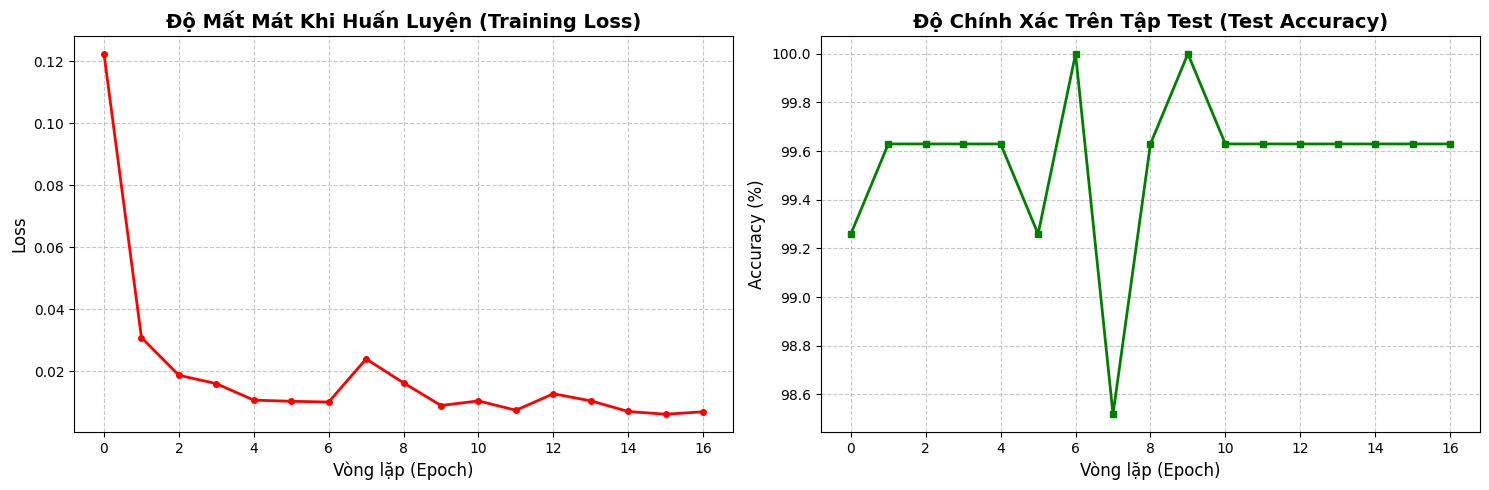

✅ Biểu đồ đã sẵn sàng! Ông chụp ảnh màn hình dán vào Báo cáo nhé.


In [ ]:
#[CELL 7] VẼ BIỂU ĐỒ QUÁ TRÌNH HỌC TẬP (LEARNING CURVE)
import matplotlib.pyplot as plt

print("📊 Đang vẽ Biểu đồ Lịch sử Học tập...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Biểu đồ Mất mát (Loss) - Càng thấp càng tốt
ax1.plot(history['train_loss'], color='red', linewidth=2, marker='o', markersize=4)
ax1.set_title('Độ Mất Mát Khi Huấn Luyện (Training Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Biểu đồ Độ chính xác (Accuracy) - Càng cao càng tốt
ax2.plot(history['test_acc'], color='green', linewidth=2, marker='s', markersize=4)
ax2.set_title('Độ Chính Xác Trên Tập Test (Test Accuracy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
print("✅ Biểu đồ đã sẵn sàng! Ông chụp ảnh màn hình dán vào Báo cáo nhé.")

🔍 Đang đánh giá chi tiết với phiên bản AI mạnh nhất (Best Model)...


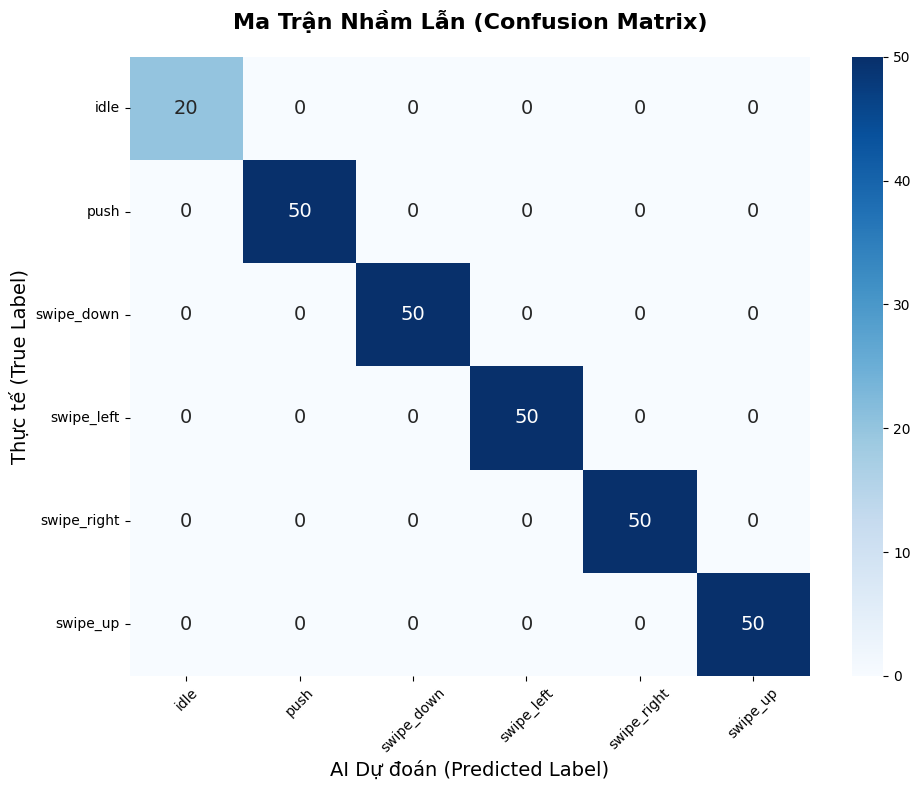

✅ Đã vẽ xong! Đường chéo chính (từ trên trái xuống dưới phải) màu càng đậm thì AI càng giỏi.


In [7]:
# [CELL 8] ĐÁNH GIÁ CHI TIẾT BẰNG MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("🔍 Đang đánh giá chi tiết với phiên bản AI mạnh nhất (Best Model)...")
model_save_path = os.path.join(SAVE_DIR, 'best_gesture_model.pth')
# 1. Tải lại Model xịn nhất đã lưu
best_model = GestureNet(num_features=FEATURES, num_classes=NUM_CLASSES).to(device)
checkpoint = torch.load(model_save_path)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

# 2. Thu thập kết quả dự đoán trên toàn bộ tập Test
all_preds =[]
all_trues =[]

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_trues.extend(labels.cpu().numpy())

# 3. Tính toán Ma trận
cm = confusion_matrix(all_trues, all_preds)

# 4. Lấy danh sách tên nhãn (labels) để hiển thị cho đẹp
label_names =[LABEL_MAPPING[i] for i in range(NUM_CLASSES)]

# 5. Vẽ Ma trận bằng Seaborn (Đẹp như tranh)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names, annot_kws={"size": 14})
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Thực tế (True Label)', fontsize=14)
plt.xlabel('AI Dự đoán (Predicted Label)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ Đã vẽ xong! Đường chéo chính (từ trên trái xuống dưới phải) màu càng đậm thì AI càng giỏi.")
print("==================================================")

In [8]:
from sklearn.metrics import classification_report

print("📈 Đánh giá chi tiết Precision, Recall, F1-Score trên từng lớp:")
print("==================================================")

# `all_trues` và `all_preds` đã được thu thập từ cell trước
report = classification_report(all_trues, all_preds, target_names=label_names, digits=4)
print(report)

print("==================================================")
print("✅ Báo cáo chi tiết hiệu suất đã có!")

📈 Đánh giá chi tiết Precision, Recall, F1-Score trên từng lớp:
              precision    recall  f1-score   support

        idle     1.0000    1.0000    1.0000        20
        push     1.0000    1.0000    1.0000        50
  swipe_down     1.0000    1.0000    1.0000        50
  swipe_left     1.0000    1.0000    1.0000        50
 swipe_right     1.0000    1.0000    1.0000        50
    swipe_up     1.0000    1.0000    1.0000        50

    accuracy                         1.0000       270
   macro avg     1.0000    1.0000    1.0000       270
weighted avg     1.0000    1.0000    1.0000       270

✅ Báo cáo chi tiết hiệu suất đã có!
